In [1]:
#Imports
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.models as models

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [2]:
#Random Seed
def set_seed(seed=42):

    random.seed(seed)

    np.random.seed(seed)
    

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

set_seed()

print("Seed Fixed")

Seed Fixed


In [3]:
#Dataset Class
import os
import cv2
import torch
import numpy as np
import random


from torch.utils.data import Dataset


class PSCDDataset(Dataset):

    def __init__(
        self,
        root,
        split_file
    ):

        self.root = root

        with open(split_file) as f:
            self.ids = [
                line.strip()
                for line in f.readlines()
            ]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):

        img_id = self.ids[idx]

        img_t0 = cv2.imread(
            os.path.join(
                self.root,
                "t0",
                img_id + ".png"
            )
        )

        img_t1 = cv2.imread(
            os.path.join(
                self.root,
                "t1",
                img_id + ".png"
            )
        )

        mask = cv2.imread(
            os.path.join(
                self.root,
                "mask",
                img_id + ".png"
            ),
            cv2.IMREAD_GRAYSCALE
        )

        sem_t0 = cv2.imread(
            os.path.join(
                self.root,
                "label_t0",
                img_id + ".png"
            )
        )

        sem_t1 = cv2.imread(
            os.path.join(
                self.root,
                "label_t1",
                img_id + ".png"
            )
        )

        attr_t0 = cv2.imread(
            os.path.join(
                self.root,
                "attribute_t0",
                img_id + ".png"
            )
        )

        attr_t1 = cv2.imread(
            os.path.join(
                self.root,
                "attribute_t1",
                img_id + ".png"
            )
        )

        h, w = mask.shape

        patch_size = 512

        x = random.randint(
            0,
            w - patch_size
        )

        y = random.randint(
            0,
            h - patch_size
        )

        img_t0 = img_t0[
            y:y+patch_size,
            x:x+patch_size
        ]

        img_t1 = img_t1[
            y:y+patch_size,
            x:x+patch_size
        ]

        mask = mask[
            y:y+patch_size,
            x:x+patch_size
        ]

        sem_t0 = sem_t0[
            y:y+patch_size,
            x:x+patch_size
        ]

        sem_t1 = sem_t1[
            y:y+patch_size,
            x:x+patch_size
        ]

        attr_t0 = attr_t0[
            y:y+patch_size,
            x:x+patch_size
        ]

        attr_t1 = attr_t1[
            y:y+patch_size,
            x:x+patch_size
        ]

        img_t0 = torch.from_numpy(
            img_t0.transpose(2,0,1)
        ).float() / 255.0

        img_t1 = torch.from_numpy(
            img_t1.transpose(2,0,1)
        ).float() / 255.0

        mask = (
            torch.from_numpy(mask) > 0
        ).long()

        return {
            "img_t0": img_t0,
            "img_t1": img_t1,
            "mask": mask
        }


dataset = PSCDDataset(
    root=r".",
    split_file=r"train.txt"
)

sample = dataset[0]

print(sample["img_t0"].shape)
print(sample["img_t1"].shape)
print(sample["mask"].shape)

print(sample["img_t0"].dtype)
print(sample["mask"].dtype)

torch.Size([3, 512, 512])
torch.Size([3, 512, 512])
torch.Size([512, 512])
torch.float32
torch.int64


In [4]:
#Create Datasets
train_dataset = PSCDDataset(
    root=".",
    split_file="./train.txt"
)

val_dataset = PSCDDataset(
    root=".",
    split_file="./val.txt"
)

test_dataset = PSCDDataset(
    root=".",
    split_file="./test.txt"
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

539
115
116


In [5]:
#Create DataLoaders
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders Created")

DataLoaders Created


In [6]:
#Build ResNet18 Encoder
import torchvision.models as models
import torch.nn as nn


class ResNet18Encoder(nn.Module):

    def __init__(self):

        super().__init__()

        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        self.conv1 = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu
        )

        self.maxpool = resnet.maxpool

        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

    def forward(self, x):

        x = self.conv1(x)

        f1 = self.layer1(
            self.maxpool(x)
        )

        f2 = self.layer2(f1)

        f3 = self.layer3(f2)

        f4 = self.layer4(f3)

        return f1, f2, f3, f4

In [7]:
#Decoder UpBlock
class UpBlock(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.up = nn.Upsample(
            scale_factor=2,
            mode="bilinear",
            align_corners=False
        )

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(),

            nn.Conv2d(
                out_channels,
                out_channels,
                3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU()
        )

    def forward(self, x, skip):

        x = self.up(x)

        x = torch.cat(
            [x, skip],
            dim=1
        )

        return self.conv(x)

In [8]:
#Decoder with Head
class ResNet18DecoderWithHead(nn.Module):

    def __init__(self):

        super().__init__()

        self.up3 = UpBlock(
            512 + 256,
            256
        )

        self.up2 = UpBlock(
            256 + 128,
            128
        )

        self.up1 = UpBlock(
            128 + 64,
            64
        )

        self.head = nn.Sequential(

            nn.Upsample(
                scale_factor=4,
                mode="bilinear",
                align_corners=False
            ),

            nn.Conv2d(
                64,
                32,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                32,
                1,
                1
            )
        )

    def forward(
        self,
        d1,
        d2,
        d3,
        d4
    ):

        x = self.up3(
            d4,
            d3
        )

        x = self.up2(
            x,
            d2
        )

        x = self.up1(
            x,
            d1
        )

        return self.head(x)

In [9]:
#MultiScale Siamese UNet
class MultiScaleSiameseUNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = ResNet18Encoder()

        self.decoder = ResNet18DecoderWithHead()

    def forward(
        self,
        t0,
        t1
    ):

        f1_0, f2_0, f3_0, f4_0 = self.encoder(t0)

        f1_1, f2_1, f3_1, f4_1 = self.encoder(t1)

        d1 = torch.abs(f1_0 - f1_1)

        d2 = torch.abs(f2_0 - f2_1)

        d3 = torch.abs(f3_0 - f3_1)

        d4 = torch.abs(f4_0 - f4_1)

        out = self.decoder(
            d1,
            d2,
            d3,
            d4
        )

        return out

In [10]:
#Verify Model
model = MultiScaleSiameseUNet().cuda()

print(model)

MultiScaleSiameseUNet(
  (encoder): ResNet18Encoder(
    (conv1): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(

In [11]:
#Forward Pass Test
torch.cuda.empty_cache()

batch = next(iter(train_loader))

img_t0 = batch["img_t0"].float().cuda()
img_t1 = batch["img_t1"].float().cuda()

with torch.no_grad():
    pred = model(
        img_t0,
        img_t1
    )

print("Forward pass OK:", pred.shape)  # torch.Size([4, 1, 512, 512])

Forward pass OK: torch.Size([4, 1, 512, 512])


In [12]:
#Metrics
def compute_metrics(preds, targets, threshold=0.5):
    """
    preds   : raw logits tensor [B, 1, H, W]
    targets : binary long tensor [B, H, W]
    Returns dict with IoU, F1, Precision, Recall, Accuracy
    """
    probs = torch.sigmoid(preds).squeeze(1)          # [B, H, W]
    pred_bin = (probs > threshold).long()            # binary predictions

    # flatten
    pred_flat = pred_bin.view(-1)
    tgt_flat  = targets.view(-1)

    TP = ((pred_flat == 1) & (tgt_flat == 1)).sum().item()
    FP = ((pred_flat == 1) & (tgt_flat == 0)).sum().item()
    TN = ((pred_flat == 0) & (tgt_flat == 0)).sum().item()
    FN = ((pred_flat == 0) & (tgt_flat == 1)).sum().item()

    eps = 1e-7

    iou       = TP / (TP + FP + FN + eps)
    precision = TP / (TP + FP + eps)
    recall    = TP / (TP + FN + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)
    accuracy  = (TP + TN) / (TP + TN + FP + FN + eps)

    return {
        "iou":       iou,
        "f1":        f1,
        "precision": precision,
        "recall":    recall,
        "accuracy":  accuracy
    }

In [13]:
#Training and Validation Functions
def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    total_loss = 0.0
    metrics_sum = {"iou": 0, "f1": 0, "precision": 0, "recall": 0, "accuracy": 0}

    for batch in tqdm(loader, desc="Train", leave=False):

        img_t0 = batch["img_t0"].float().to(device)
        img_t1 = batch["img_t1"].float().to(device)
        mask   = batch["mask"].to(device)             # [B, H, W] long

        optimizer.zero_grad()

        pred = model(img_t0, img_t1)                  # [B, 1, H, W]

        loss = criterion(
            pred.squeeze(1).float(),
            mask.float()
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        with torch.no_grad():
            m = compute_metrics(pred, mask)
            for k in metrics_sum:
                metrics_sum[k] += m[k]

    n = len(loader)
    return total_loss / n, {k: v / n for k, v in metrics_sum.items()}


@torch.no_grad()
def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0.0
    metrics_sum = {"iou": 0, "f1": 0, "precision": 0, "recall": 0, "accuracy": 0}

    for batch in tqdm(loader, desc="Val  ", leave=False):

        img_t0 = batch["img_t0"].float().to(device)
        img_t1 = batch["img_t1"].float().to(device)
        mask   = batch["mask"].to(device)

        pred = model(img_t0, img_t1)

        loss = criterion(
            pred.squeeze(1).float(),
            mask.float()
        )

        total_loss += loss.item()

        m = compute_metrics(pred, mask)
        for k in metrics_sum:
            metrics_sum[k] += m[k]

    n = len(loader)
    return total_loss / n, {k: v / n for k, v in metrics_sum.items()}

In [14]:
#Training Config
EPOCHS        = 150
PATIENCE      = 15          # stop if val IoU doesn't improve for 15 epochs
LR            = 1e-4
SAVE_PATH     = "best_model.pth"
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {DEVICE}")
print(f"Epochs : {EPOCHS}")
print(f"Patience (IoU) : {PATIENCE}")

Device : cuda
Epochs : 150
Patience (IoU) : 15


In [16]:
#Loss, Optimizer, Scheduler
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)

# Reduce LR by 0.5 if val IoU doesn't improve for 7 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=7
)

print("Loss / Optimizer / Scheduler ready")

Loss / Optimizer / Scheduler ready


In [17]:
#Training Loop — 150 Epochs with IoU Early Stopping
history = {
    "train_loss": [], "val_loss": [],
    "train_iou":  [], "val_iou":  [],
    "train_f1":   [], "val_f1":   [],
    "train_prec": [], "val_prec": [],
    "train_rec":  [], "val_rec":  [],
    "train_acc":  [], "val_acc":  []
}

best_val_iou    = 0.0
patience_count  = 0

print(f"{'Epoch':>6} | {'TrLoss':>7} | {'TrIoU':>6} | {'TrF1':>6} | "
      f"{'VaLoss':>7} | {'VaIoU':>6} | {'VaF1':>6} | {'VaPrec':>7} | "
      f"{'VaRec':>6} | {'VaAcc':>6} | {'LR':>8} | {'Pat':>3}")
print("-" * 105)

for epoch in range(1, EPOCHS + 1):

    train_loss, train_m = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE
    )

    val_loss, val_m = evaluate(
        model, val_loader, criterion, DEVICE
    )

    # Step LR scheduler on val IoU
    scheduler.step(val_m["iou"])

    # Log history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_iou"].append(train_m["iou"])
    history["val_iou"].append(val_m["iou"])
    history["train_f1"].append(train_m["f1"])
    history["val_f1"].append(val_m["f1"])
    history["train_prec"].append(train_m["precision"])
    history["val_prec"].append(val_m["precision"])
    history["train_rec"].append(train_m["recall"])
    history["val_rec"].append(val_m["recall"])
    history["train_acc"].append(train_m["accuracy"])
    history["val_acc"].append(val_m["accuracy"])

    current_lr = optimizer.param_groups[0]["lr"]

    # Early stopping on val IoU
    if val_m["iou"] > best_val_iou:
        best_val_iou   = val_m["iou"]
        patience_count = 0
        torch.save(model.state_dict(), SAVE_PATH)
        tag = "  ← best"
    else:
        patience_count += 1
        tag = ""

    print(
        f"{epoch:>6} | {train_loss:>7.4f} | {train_m['iou']:>6.4f} | {train_m['f1']:>6.4f} | "
        f"{val_loss:>7.4f} | {val_m['iou']:>6.4f} | {val_m['f1']:>6.4f} | "
        f"{val_m['precision']:>7.4f} | {val_m['recall']:>6.4f} | {val_m['accuracy']:>6.4f} | "
        f"{current_lr:>8.2e} | {patience_count:>3}{tag}"
    )

    if patience_count >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}. "
              f"Val IoU did not improve for {PATIENCE} consecutive epochs.")
        break

print(f"\nBest Val IoU : {best_val_iou:.4f}")
print(f"Model saved  : {SAVE_PATH}")

 Epoch |  TrLoss |  TrIoU |   TrF1 |  VaLoss |  VaIoU |   VaF1 |  VaPrec |  VaRec |  VaAcc |       LR | Pat
---------------------------------------------------------------------------------------------------------


     1 |  0.3961 | 0.3413 | 0.4954 |  0.2753 | 0.5198 | 0.6692 |  0.7274 | 0.6400 | 0.8809 | 1.00e-04 |   0  ← best


     2 |  0.3345 | 0.4090 | 0.5674 |  0.2552 | 0.5148 | 0.6666 |  0.7625 | 0.6189 | 0.8884 | 1.00e-04 |   1


     3 |  0.3066 | 0.4374 | 0.5972 |  0.2750 | 0.4991 | 0.6581 |  0.7142 | 0.6405 | 0.8818 | 1.00e-04 |   2


     4 |  0.3054 | 0.4451 | 0.6051 |  0.2732 | 0.4707 | 0.6251 |  0.8240 | 0.5243 | 0.8881 | 1.00e-04 |   3


...

    62 |  0.1507 | 0.7024 | 0.8139 |  0.1886 | 0.6603 | 0.7889 |  0.8361 | 0.7636 | 0.9266 | 6.25e-06 |  11


    63 |  0.1439 | 0.7223 | 0.8299 |  0.1902 | 0.6140 | 0.7480 |  0.8076 | 0.7189 | 0.9208 | 6.25e-06 |  12


    64 |  0.1478 | 0.7072 | 0.8178 |  0.1791 | 0.6845 | 0.8024 |  0.8334 | 0.7857 | 0.9308 | 6.25e-06 |  13


    65 |  0.1471 | 0.7141 | 0.8250 |  0.1979 | 0.6244 | 0.7552 |  0.8237 | 0.7236 | 0.9224 | 6.25e-06 |  14


    66 |  0.1469 | 0.7192 | 0.8269 |  0.2125 | 0.6309 | 0.7576 |  0.8013 | 0.7352 | 0.9183 | 6.25e-06 |  15

Early stopping at epoch 66. Val IoU did not improve for 15 consecutive epochs.

Best Val IoU : 0.7062
Model saved  : best_model.pth


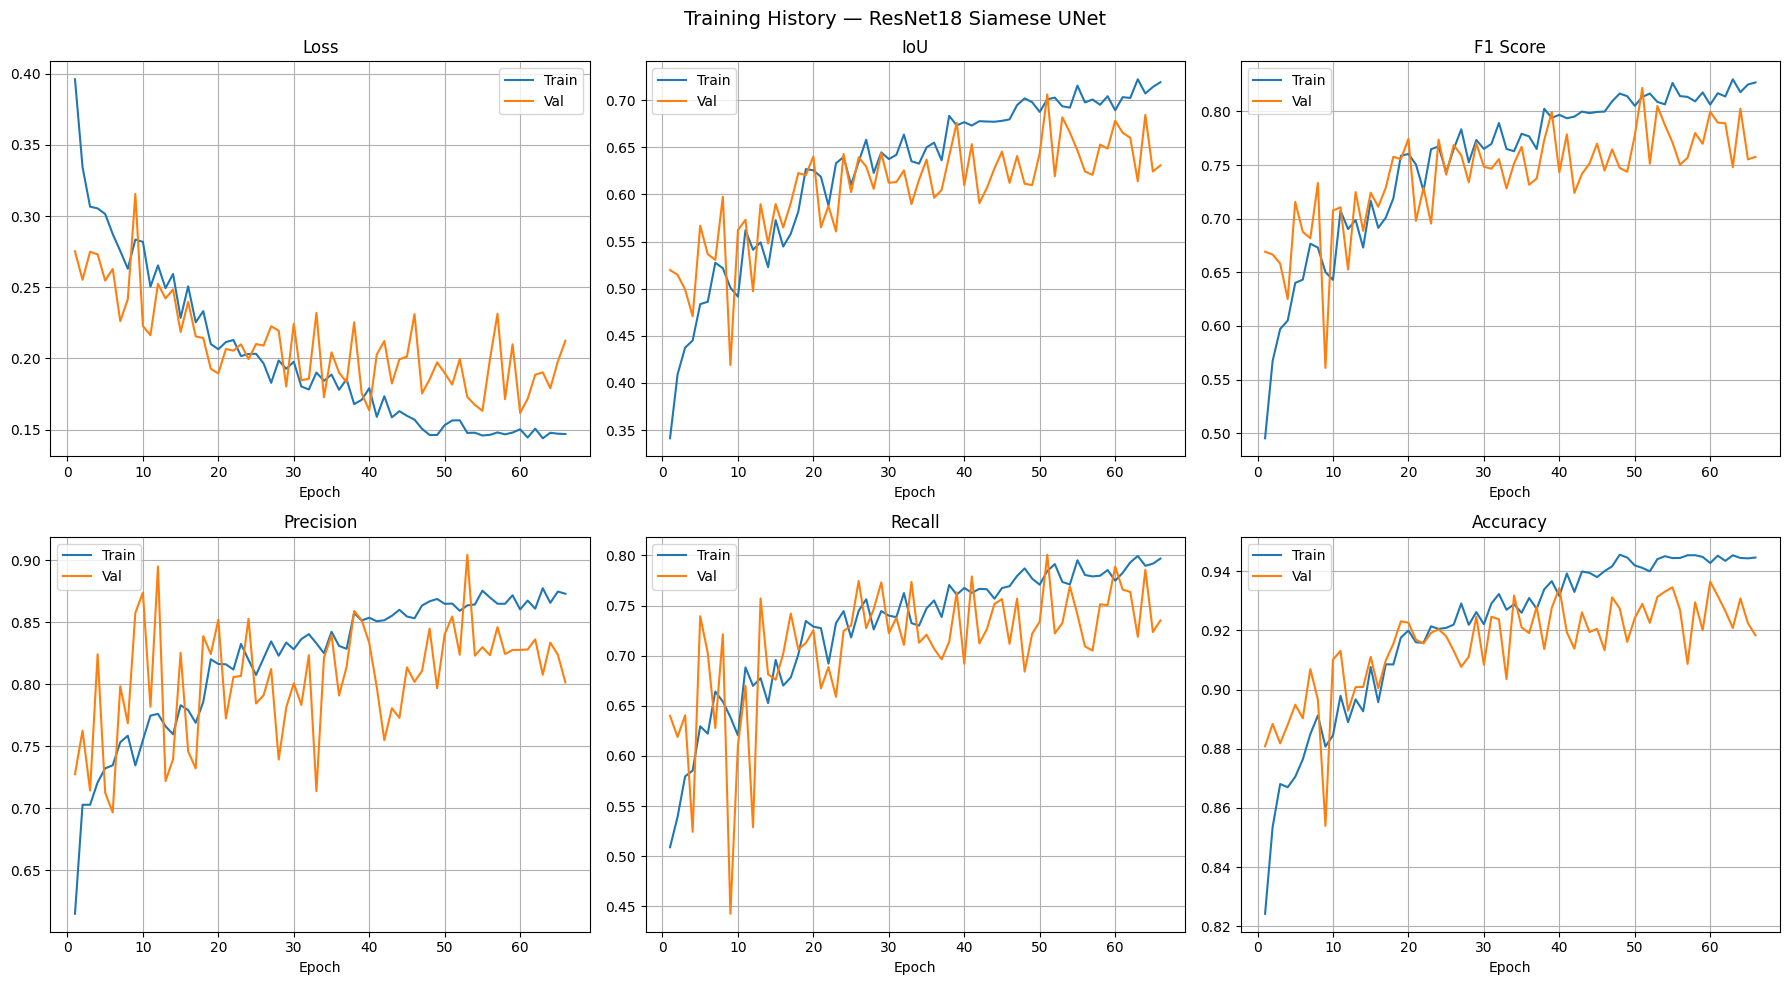

Saved: training_curves.png


In [18]:
#Plot Training Curves
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Training History — ResNet18 Siamese UNet", fontsize=14)

pairs = [
    ("Loss",      "train_loss", "val_loss"),
    ("IoU",       "train_iou",  "val_iou"),
    ("F1 Score",  "train_f1",   "val_f1"),
    ("Precision", "train_prec", "val_prec"),
    ("Recall",    "train_rec",  "val_rec"),
    ("Accuracy",  "train_acc",  "val_acc"),
]

for ax, (title, tr_key, va_key) in zip(axes.flat, pairs):
    ax.plot(epochs_ran, history[tr_key], label="Train")
    ax.plot(epochs_ran, history[va_key], label="Val")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Saved: training_curves.png")

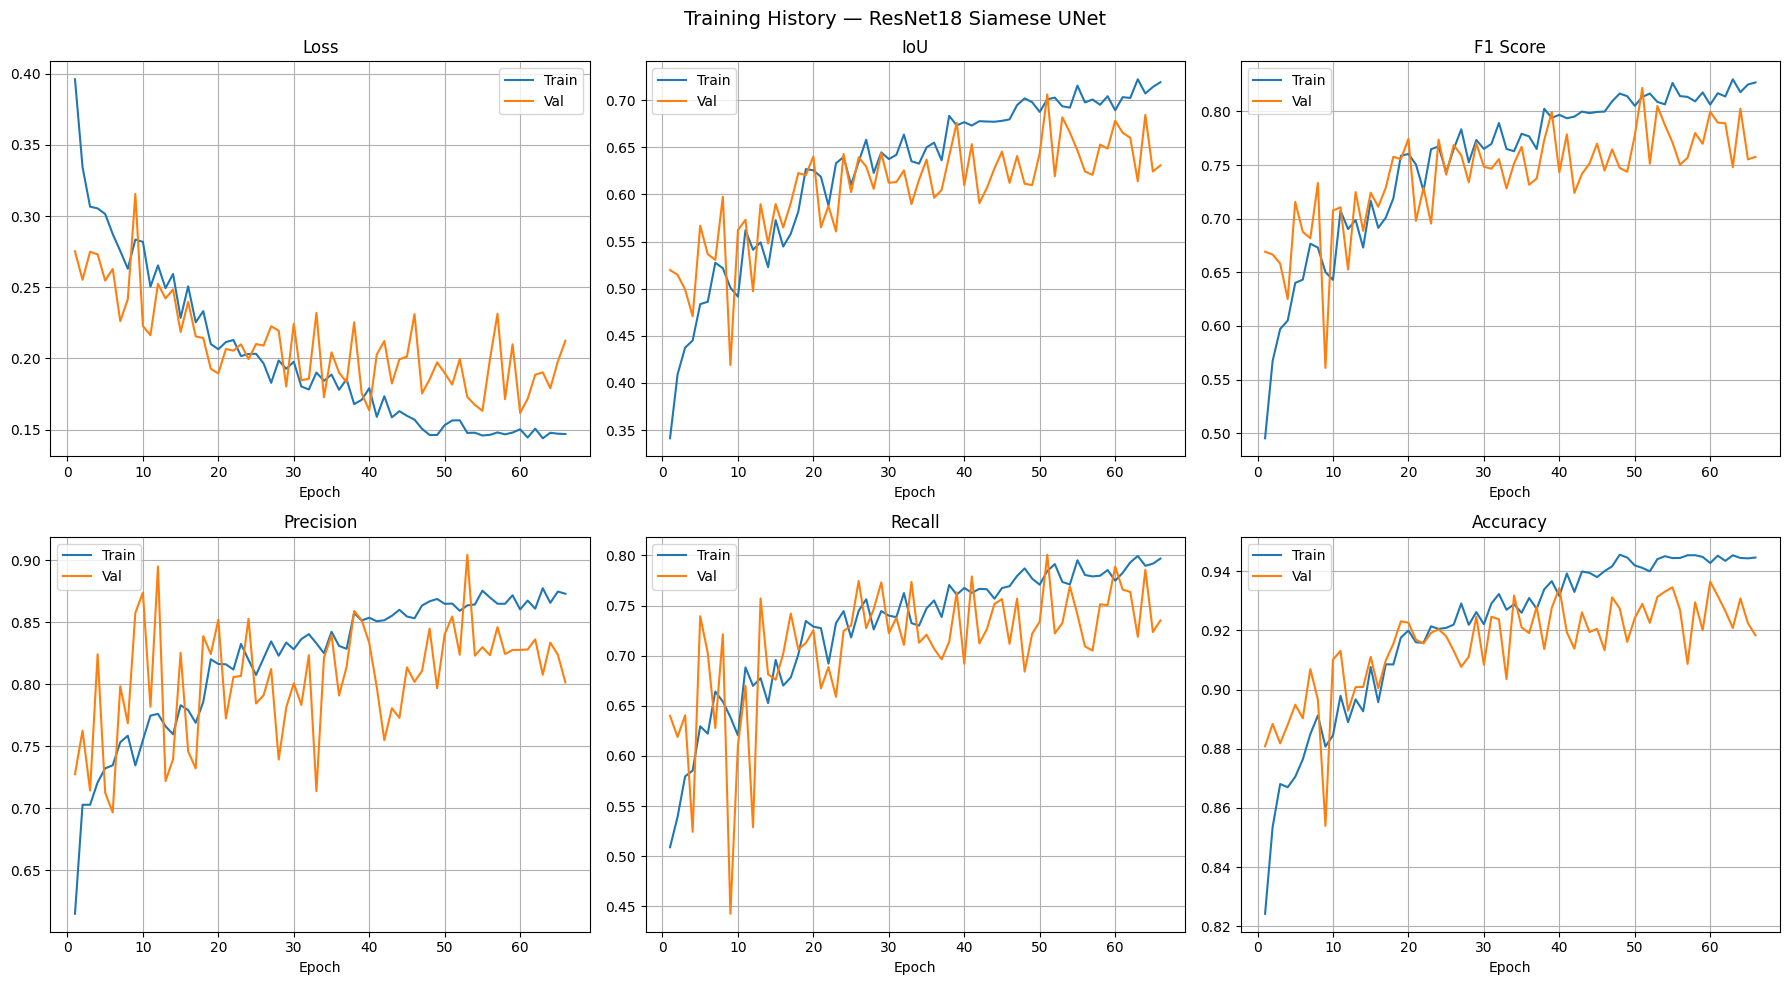

Saved: training_curves.png


In [19]:
#Plot Training Curves
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Training History — ResNet18 Siamese UNet", fontsize=14)

pairs = [
    ("Loss",      "train_loss", "val_loss"),
    ("IoU",       "train_iou",  "val_iou"),
    ("F1 Score",  "train_f1",   "val_f1"),
    ("Precision", "train_prec", "val_prec"),
    ("Recall",    "train_rec",  "val_rec"),
    ("Accuracy",  "train_acc",  "val_acc"),
]

for ax, (title, tr_key, va_key) in zip(axes.flat, pairs):
    ax.plot(epochs_ran, history[tr_key], label="Train")
    ax.plot(epochs_ran, history[va_key], label="Val")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Saved: training_curves.png")